In [9]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from math import log
import numpy as np

wpm = 0

bigrams = {
    k: int(v) for (k, v) in [l.strip().split("\t") for l in open("ngrams/bigrams.txt")]
}

x = []
y = []
c = []

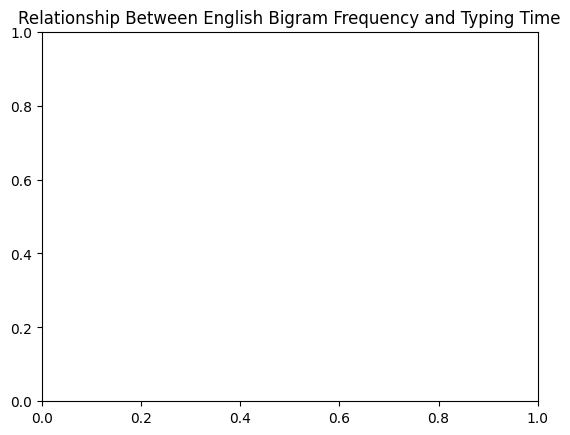

In [18]:
title = f"Relationship Between English Bigram Frequency and Typing Time at >{wpm} WPM"

if wpm == 0:
    title = "Relationship Between English Bigram Frequency and Typing Time"

plt.title(title)

with open(f"nstrokes/bistrokes_{wpm}.txt") as file:
    for l in file:
        bistroke = l[:2]
        times = list(map(int, l[3:].split(", ")))
        avg = int(sum(times) / len(times))

        # print(f"{bistroke}: {avg}")
        if not any([c in "~!@#$%^&*()_+QWERTYUIOP{}|ASDFGHJKL:\"ZXCVBNM<>?" for c in bistroke]):
            y.append(avg)
            x.append(bigrams[bistroke])
            c.append("red" if avg < -1 else "#1f77b4")
            # print("".join(bistroke[::-1]))
            # if (
            #    bistroke in list(bigrams.keys())[:20]
            #    or "".join(bistroke[::-1]) in list(bigrams.keys())[:20]
            # ):
            plt.annotate(bistroke, xy=(bigrams[bistroke], avg))

/tmp/ipykernel_5939/1369968536.py:2: RuntimeWarning: invalid value encountered in log
  return a * np.log(x + b) + c


-36.062385788821075 348.02796292619934 694.9586914282002


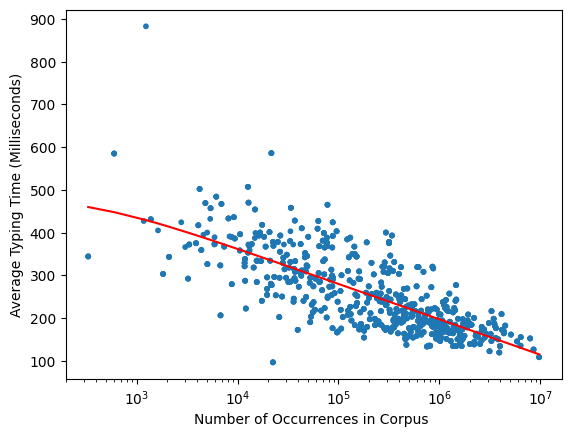

In [17]:
def log_func(x, a, b, c):
    return a * np.log(x + b) + c


popt, pcov = curve_fit(log_func, x, y)
new_y = log_func(np.sort(x), *popt)
print(*popt)
plt.scatter(x, y, c=c, s=10)
plt.plot(np.sort(x), new_y, c="red")
plt.xlabel("Number of Occurrences in Corpus ")
plt.ylabel("Average Typing Time (Milliseconds)")
plt.xscale("log")
plt.show()